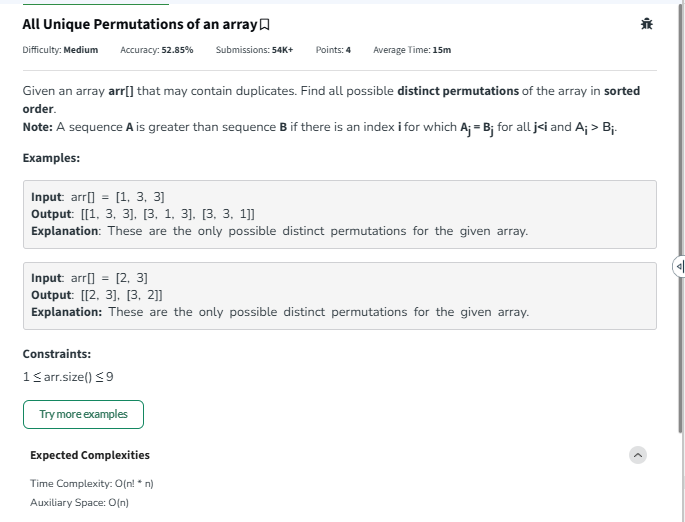

🧠 Core Logic Breakdown
1. Backtracking via Swapping
Instead of creating new arrays for every step, the algorithm builds permutations in-place by swapping elements.

It fixes one element at the current index idx and recursively solves for the rest of the array (idx + 1 to n).

Base Case: When idx == n, a complete unique permutation is formed and added to the result list ans.

Backtrack Step: After the recursive call returns, the swap is undone (swapped back) to restore the array to its original state for the next iteration.

| Step | `idx` | `i` | `arr` before swap | `seen` at level `idx` | Action                     | `arr` after swap | Recursion/Backtrack         | `ans` (so far)                  |
|------|-------|-----|-------------------|------------------------|----------------------------|------------------|-----------------------------|---------------------------------|
| 1    | 0     | 0   | [1, 2, 1]         | {}                     | Swap(0,0), add 1 to seen   | [1, 2, 1]        | Recurse idx=1               | []                              |
| 2    | 1     | 1   | [1, 2, 1]         | {}                     | Swap(1,1), add 2 to seen   | [1, 2, 1]        | Recurse idx=2               | []                              |
| 3    | 2     | 2   | [1, 2, 1]         | {}                     | Swap(2,2), add 1 to seen   | [1, 2, 1]        | Base case → add to `ans`    | [[1, 2, 1]]                     |
| 4    | 2     | -   | [1, 2, 1]         | {1}                    | Backtrack (undo swap)      | [1, 2, 1]        | Return to idx=1             | [[1, 2, 1]]                     |
| 5    | 1     | 2   | [1, 2, 1]         | {2}                    | arr[2]=1 not in seen → add | [1, 1, 2]        | Swap(2,1), Recurse idx=2    | [[1, 2, 1]]                     |
| 6    | 2     | 2   | [1, 1, 2]         | {}                     | Swap(2,2), add 2 to seen   | [1, 1, 2]        | Base case → add to `ans`    | [[1, 2, 1], [1, 1, 2]]          |
| 7    | 2     | -   | [1, 1, 2]         | {2}                    | Backtrack                  | [1, 1, 2]        | Return to idx=1             | [[1, 2, 1], [1, 1, 2]]          |
| 8    | 1     | -   | [1, 1, 2]         | {2,1}                  | Backtrack                  | [1, 2, 1]        | Return to idx=0             | [[1, 2, 1], [1, 1, 2]]          |
| 9    | 0     | 1   | [1, 2, 1]         | {1}                    | arr[1]=2 not in seen → add | [2, 1, 1]        | Swap(1,0), Recurse idx=1    | [[1, 2, 1], [1, 1, 2]]          |
|10    | 1     | 1   | [2, 1, 1]         | {}                     | Swap(1,1), add 1 to seen   | [2, 1, 1]        | Recurse idx=2               | [[1, 2, 1], [1, 1, 2]]          |
|11    | 2     | 2   | [2, 1, 1]         | {}                     | Swap(2,2), add 1 to seen   | [2, 1, 1]        | Base case → add to `ans`    | [[1, 2, 1], [1, 1, 2], [2, 1, 1]] |
|12    | 2     | -   | [2, 1, 1]         | {1}                    | Backtrack                  | [2, 1, 1]        | Return to idx=1             | [[1, 2, 1], [1, 1, 2], [2, 1, 1]] |
|13    | 1     | 2   | [2, 1, 1]         | {1}                    | arr[2]=1 in seen → skip    | [2, 1, 1]        | Continue loop               | [[1, 2, 1], [1, 1, 2], [2, 1, 1]] |
|14    | 1     | -   | [2, 1, 1]         | {1}                    | Backtrack                  | [1, 2, 1]        | Return to idx=0             | [[1, 2, 1], [1, 1, 2], [2, 1, 1]] |
|15    | 0     | 2   | [1, 2, 1]         | {1,2}                  | arr[2]=1 in seen → skip    | [1, 2, 1]        | End loop                    | [[1, 2, 1], [1, 1, 2], [2, 1, 1]] |

In [ ]:
class Solution:
    def uniquePerms(self, arr):
        ans = []
        n = len(arr)
        arr.sort()  # Sort to handle duplicates easily
        self.permuts(0, n, arr, ans)
        
        # Remove duplicates if any slip through (optional if logic is perfect, but safe)
        # However, with the skip logic below, duplicates are prevented during generation.
        ans.sort()
        return ans
    
    def permuts(self, idx, n, arr, ans):
        # Base Case
        if idx == n:
            ans.append(arr[:])  # Append a COPY, not the reference
            return
        
        # Use a set to track used elements at this specific recursion level
        # This prevents swapping the same value into the 'idx' position twice
        seen = set()
        
        for i in range(idx, n):
            if arr[i] in seen:
                continue
            seen.add(arr[i])
            
            # Swap
            self.swap(i, idx, arr)
            
            # Recurse
            self.permuts(idx + 1, n, arr, ans)
            
            # Backtrack (Undo swap)
            self.swap(i, idx, arr)
        
    def swap(self, i, j, arr):
        arr[i], arr[j] = arr[j], arr[i]   



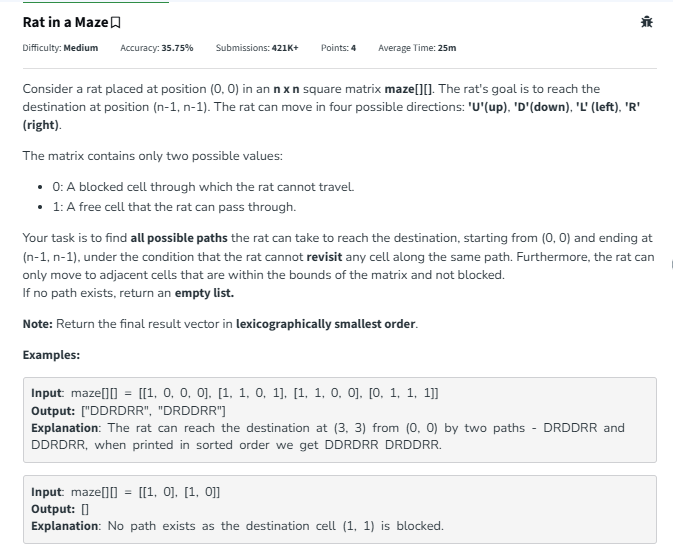
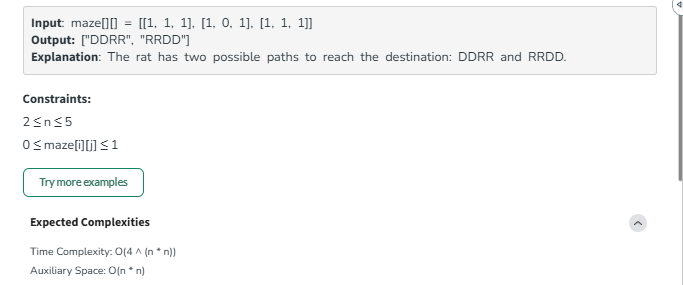

In [ ]:
class Solution:
    def ratInMaze(self, maze):
        # code here
        n = len(maze)
        m = len(maze[0])
        tag = ''
        ans = []
        
        if maze[0][0] == 0:
            return ans
        
        self.paths(0, 0, n, m, maze, tag, ans)
        
        ans.sort()
        return ans 
        
    def paths(self, r, c, n, m, maze, tag, ans):
        
        # Base  
        if r == n - 1 and c == m - 1:
            ans.append(tag[:])
            
        
        maze[r][c] = -1
        
        # DOWN
        if r + 1 < n and maze[r + 1][c] != -1 and maze[r + 1][c] != 0:
            self.paths(r + 1, c, n, m, maze, tag + 'D', ans)
            
        # LEFT
        if c - 1 >= 0 and maze[r][c - 1] != -1 and maze[r][c - 1] != 0:
            self.paths(r, c - 1, n, m, maze, tag + 'L', ans)
            
        # RIGHT
        if c + 1 < m and maze[r][c + 1] != -1 and maze[r][c + 1] != 0:
            self.paths(r, c + 1, n, m, maze, tag + 'R', ans)
        
        # UP
        if r - 1 >= 0 and maze[r - 1][c] != -1 and maze[r - 1][c] != 0:
            self.paths(r - 1, c, n, m, maze, tag + 'U', ans)

        # backtracking step to undo the changes
        maze[r][c] = 1
        
        return 
        

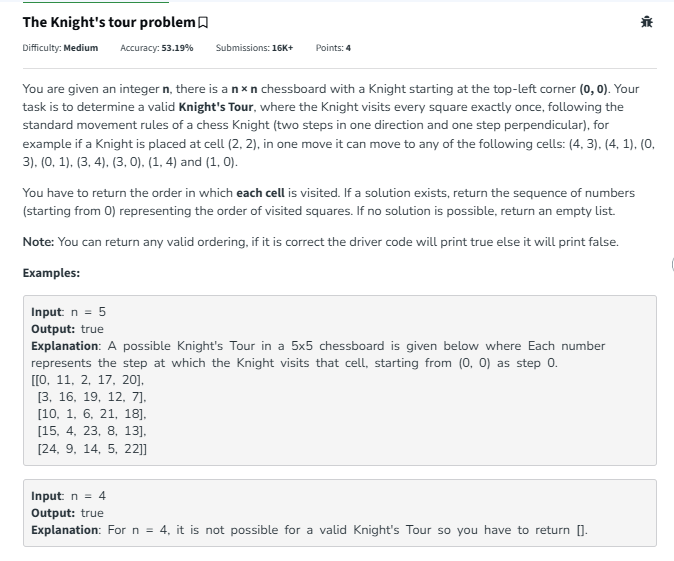
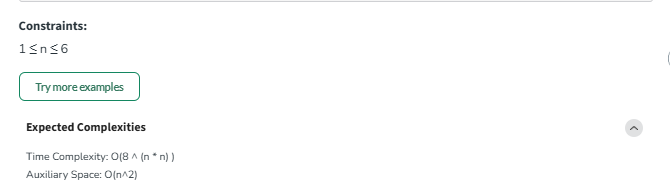

In [ ]:
class Solution:
    def __init__(self):
        # Define the 8 possible knight moves (same as Java dr/dc)
        self.dr = [-2, -2, -1, 1, 2, 2, 1, -1]
        self.dc = [-1, 1, 2, 2, 1, -1, -2, -2]

    def knightTour(self, n):
        # Initialize the board with -1 (unvisited)
        # Equivalent to: ArrayList<ArrayList<Integer>> ans filled with -1
        ans = [[-1 for _ in range(n)] for _ in range(n)]
        
        # Start the recursion from (0, 0) with count = 0
        if self.fun(0, 0, 0, n, ans):
            return ans
        else:
            # Return empty list if no tour exists (matches Java: new ArrayList<>() )
            return []

    def fun(self, r, c, count, n, ans):
        # Base Case: If all cells are visited (count reaches n*n - 1)
        if count == (n * n) - 1:
            ans[r][c] = count
            return True
        
        # Mark the current cell with the current step count
        ans[r][c] = count
        
        # Try all 8 possible moves
        for i in range(8):
            nr = r + self.dr[i]
            nc = c + self.dc[i]
            
            # Check if the new position is valid and unvisited
            if self.isValid(nr, nc, n, ans):
                # Recurse
                if self.fun(nr, nc, count + 1, n, ans):
                    return True
        
        # Backtrack: Undo the change if no path leads to a solution
        ans[r][c] = -1
        return False

    def isValid(self, r, c, n, ans):
        # Check boundaries and if the cell is unvisited (-1)
        return 0 <= r < n and 0 <= c < n and ans[r][c] == -1   

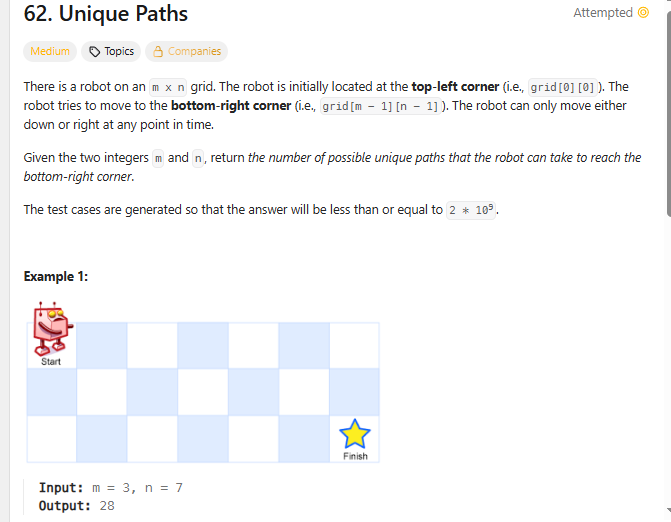
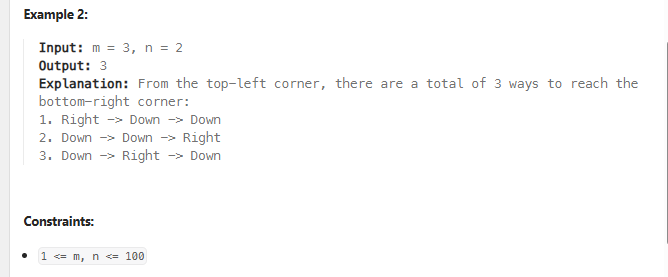

In [ ]:
class Solution(object):
    def uniquePaths(self, m, n):
        return self.pathgenerator(0, 0, m, n)

    def pathgenerator(self, r, c, m, n):
        # Base Case: Reached the bottom-right corner
        if r == m - 1 and c == n - 1:
            return 1
        
        count = 0
        # Move Down
        if r + 1 < m:
            count += self.pathgenerator(r + 1, c, m, n)
        
        # Move Right
        if c + 1 < n:
            count += self.pathgenerator(r, c + 1, m, n)
            
        return count   

HomeWork 

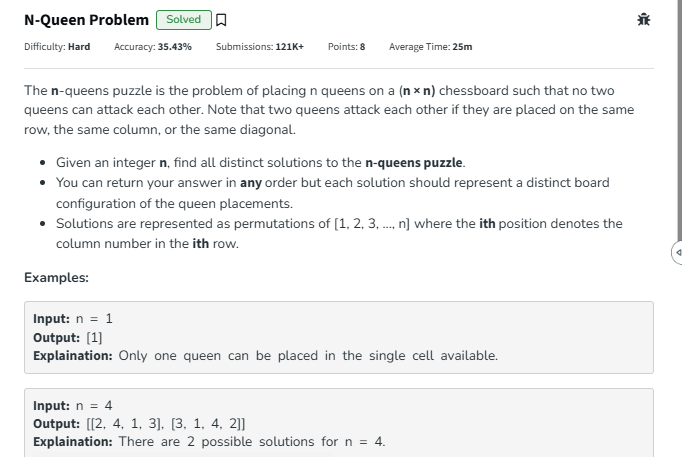
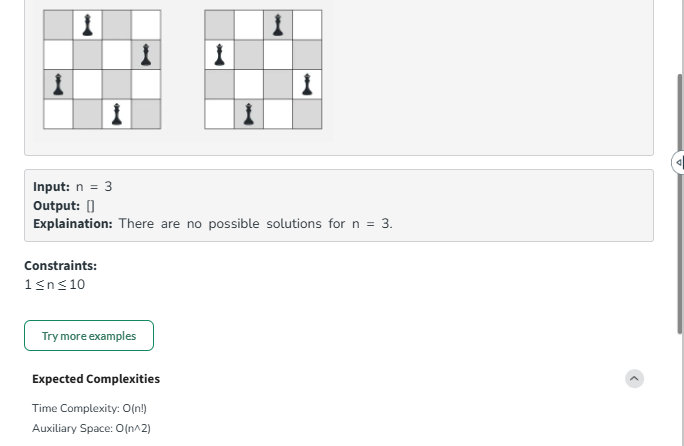

In [ ]:
class Solution:
    def nQueen(self, n):

        ans = []
        
        mat = [[0] * n for i in range(n)]
        
        self.solve(0, n, mat, ans)
        
        return ans
        
        
    def solve(self, r, n, mat, ans):
        
        # base condn
        if r == n:
            soln = []
            for i in range(n):
                for j in range(n):
                    if mat[i][j] == 1:
                        soln.append(j + 1)
            ans.append(soln)
            return 
            
         
        for col in range(n):
               
            if self.is_safe(r, n, col, mat):
                mat[r][col] = 1
                self.solve(r + 1, n, mat, ans)
                mat[r][col] = 0
                
            
    def is_safe(self, row, n, col, mat):
        
        # checking currnt col
        
        for i in range(row + 1):
            if mat[i][col] == 1:
                return False
        
        # checking left upper diagonal
        
        i, j = row, col
        while i >= 0 and j >= 0:
            if mat[i][j] == 1:
                return False
            i -= 1
            j -= 1
        
        
        # checking right upper daigonal
        
        i, j = row, col
        while i >= 0 and j < n:
            if mat[i][j] == 1:
                return False
            i -= 1
            j += 1
            
        return True

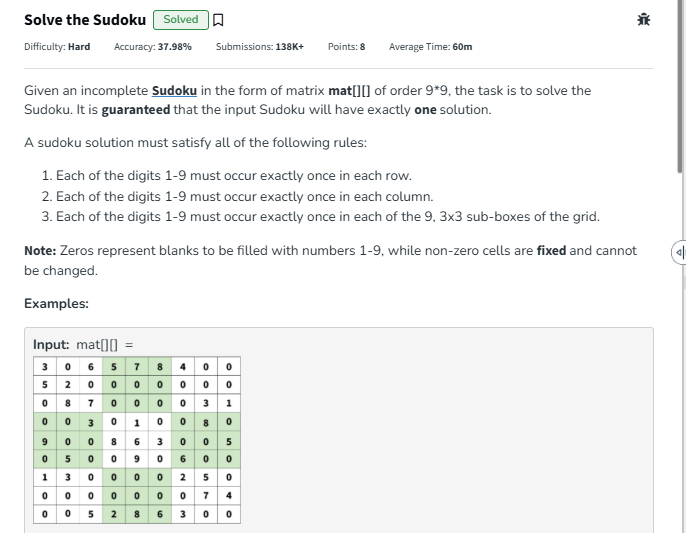
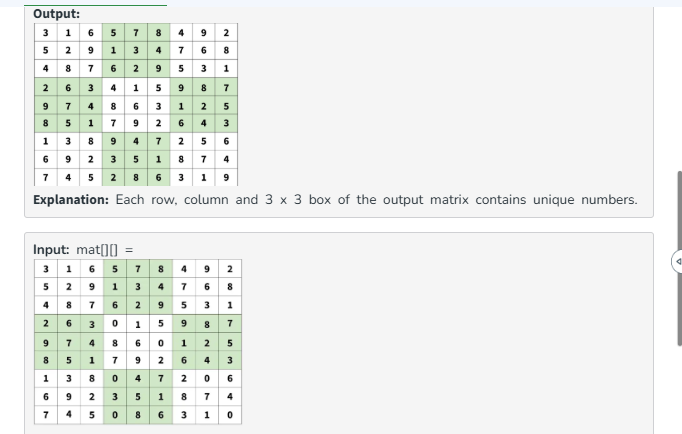
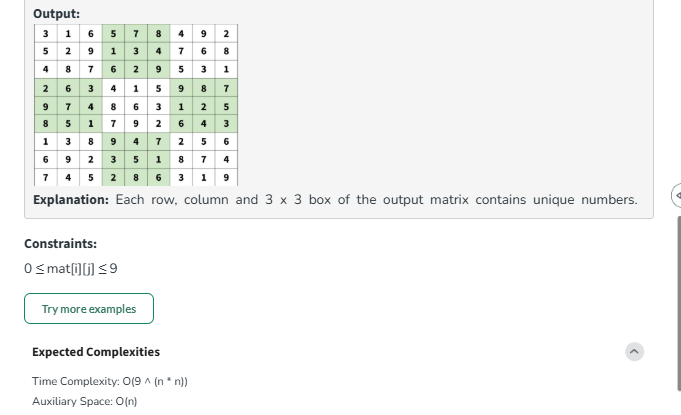

In [ ]:
class Solution:
    def solveSudoku(self, mat):
        n = len(mat)
        self.solve(0, 0, mat)
        return mat
        
        # Base Cond
        
    def solve(self, row, col, mat):
        
        # base cases
        if col == 9:
            return self.solve(row + 1, 0, mat)
            
        if row == 9:
            return True
            
        if mat[row][col] != 0:
            return self.solve(row, col + 1, mat)
        
        # Insert elements in the mat
        for i in range(1, 10):
            
            if self.is_safe(row, col, mat, i):
                    
                mat[row][col] = i
                    
                if self.solve(row, col + 1, mat):
                    return True
                        
                mat[row][col] = 0
                        
                    
        return False
            
        
                    
    def is_safe(self, r, c, mat, curr):
        
        # checking row
        for row in range(9):
            if mat[row][c] == curr:
                return False
                
        # cheking the column
        for col in range(9):
            if mat[r][col] == curr:
                return False
        
        # checking the sub-matrix
        start_row, start_col = 3 * (r // 3), 3 * (c // 3)
        
        for row in range(start_row, start_row + 3):
            for col in range(start_col, start_col + 3):
                if mat[row][col] == curr:
                    return False
                    
        return True
            
        